# ЛАБОРАТОРНАЯ РАБОТА №6
# Введение в методы оптимизации
# Вариант №12

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

print("="*60)
print("ЛАБОРАТОРНАЯ РАБОТА №6")
print("Введение в методы оптимизации")
print("Вариант №12")
print("="*60)

ЛАБОРАТОРНАЯ РАБОТА №6
Введение в методы оптимизации
Вариант №12


# 1. Задаем переменные и функции

In [2]:
x1, x2, l1, l2 = sp.symbols('x1 x2 l1 l2')

# Целевая функция
f = 2 * (x1**4 - x2**2)**2 + 3 * x1 * x2

# Ограничения
g1 = x1**2 + x2**2 - 6  # x1^2 + x2^2 <= 6
g2 = -x1                 # -x1 <= 0 => x1 >= 0

print("\n" + "="*60)
print("1. ЦЕЛЕВАЯ ФУНКЦИЯ И ОГРАНИЧЕНИЯ")
print("="*60)
print(f"f(x1, x2) = {f}")
print(f"g1(x1, x2) = {g1} <= 0")
print(f"g2(x1, x2) = {g2} <= 0")


1. ЦЕЛЕВАЯ ФУНКЦИЯ И ОГРАНИЧЕНИЯ
f(x1, x2) = 3*x1*x2 + 2*(x1**4 - x2**2)**2
g1(x1, x2) = x1**2 + x2**2 - 6 <= 0
g2(x1, x2) = -x1 <= 0


# 2. Составляем функцию Лагранжа

In [3]:
L = f + l1 * g1 + l2 * g2

print("\n" + "="*60)
print("2. ФУНКЦИЯ ЛАГРАНЖА")
print("="*60)
print(f"L = {L}")


2. ФУНКЦИЯ ЛАГРАНЖА
L = l1*(x1**2 + x2**2 - 6) - l2*x1 + 3*x1*x2 + 2*(x1**4 - x2**2)**2


# 3. Необходимые условия первого порядка

In [4]:
dL_dx1 = sp.diff(L, x1)
dL_dx2 = sp.diff(L, x2)

print("\n" + "="*60)
print("3. НЕОБХОДИМЫЕ УСЛОВИЯ ПЕРВОГО ПОРЯДКА")
print("="*60)
print(f"∂L/∂x1 = {dL_dx1} = 0")
print(f"∂L/∂x2 = {dL_dx2} = 0")
print(f"λ1·g1 = {l1 * g1} = 0")
print(f"λ2·g2 = {l2 * g2} = 0")

# Система уравнений
equations = [dL_dx1, dL_dx2, l1 * g1, l2 * g2]


3. НЕОБХОДИМЫЕ УСЛОВИЯ ПЕРВОГО ПОРЯДКА
∂L/∂x1 = 2*l1*x1 - l2 + 16*x1**3*(x1**4 - x2**2) + 3*x2 = 0
∂L/∂x2 = 2*l1*x2 + 3*x1 - 8*x2*(x1**4 - x2**2) = 0
λ1·g1 = l1*(x1**2 + x2**2 - 6) = 0
λ2·g2 = -l2*x1 = 0


# 4. Решение системы уравнений

In [5]:
print("\n" + "="*60)
print("4. РЕШЕНИЕ СИСТЕМЫ УРАВНЕНИЙ")
print("="*60)

print("Решаем систему...")
solutions = sp.solve(equations, (x1, x2, l1, l2))

print(f"\nНайдено {len(solutions)} стационарных точек.")

# Отфильтруем только действительные (не комплексные) точки
real_solutions = []
for sol in solutions:
    is_real = True
    for val in sol:
        if sp.im(val) != 0:
            is_real = False
            break
    if is_real:
        real_solutions.append(sol)

print(f"Действительных точек: {len(real_solutions)}")


4. РЕШЕНИЕ СИСТЕМЫ УРАВНЕНИЙ
Решаем систему...

Найдено 13 стационарных точек.
Действительных точек: 3


# 5. Анализ стационарных точек

In [6]:
print("\n" + "="*60)
print("5. АНАЛИЗ СТАЦИОНАРНЫХ ТОЧЕК")
print("="*60)

results = []
feasible_count = 0

for i, sol in enumerate(real_solutions):
    x1_val, x2_val, l1_val, l2_val = sol
    
    f_val = f.subs({x1: x1_val, x2: x2_val})
    g1_val = g1.subs({x1: x1_val, x2: x2_val})
    g2_val = g2.subs({x1: x1_val, x2: x2_val})
    
    is_feasible = (g1_val <= 0) and (g2_val <= 0)
    if is_feasible:
        feasible_count += 1
    
    results.append({
        'num': i + 1,
        'x1': x1_val,
        'x2': x2_val,
        'l1': l1_val,
        'l2': l2_val,
        'f': f_val,
        'g1': g1_val,
        'g2': g2_val,
        'feasible': is_feasible
    })
    
    print(f"\nТочка {i+1}:")
    print(f"  x1 = {x1_val}")
    print(f"  x2 = {x2_val}")
    print(f"  λ1 = {l1_val}")
    print(f"  λ2 = {l2_val}")
    print(f"  f(x) = {f_val}")
    print(f"  g1 = {g1_val} {'(активно)' if g1_val == 0 else '(пассивно)'}")
    print(f"  g2 = {g2_val} {'(активно)' if g2_val == 0 else '(пассивно)'}")
    print(f"  Допустима: {'ДА' if is_feasible else 'НЕТ'}")

print(f"\nВсего допустимых стационарных точек: {feasible_count}")


5. АНАЛИЗ СТАЦИОНАРНЫХ ТОЧЕК

Точка 1:
  x1 = 0
  x2 = -sqrt(6)
  λ1 = -24
  λ2 = -3*sqrt(6)
  f(x) = 72
  g1 = 0 (активно)
  g2 = 0 (активно)
  Допустима: ДА

Точка 2:
  x1 = 0
  x2 = sqrt(6)
  λ1 = -24
  λ2 = 3*sqrt(6)
  f(x) = 72
  g1 = 0 (активно)
  g2 = 0 (активно)
  Допустима: ДА

Точка 3:
  x1 = 0
  x2 = 0
  λ1 = 0
  λ2 = 0
  f(x) = 0
  g1 = -6 (пассивно)
  g2 = 0 (активно)
  Допустима: ДА

Всего допустимых стационарных точек: 3


# 6. Матрица Гессе

In [7]:
H = sp.hessian(L, [x1, x2])

print("\n" + "="*60)
print("6. МАТРИЦА ГЕССЕ ФУНКЦИИ ЛАГРАНЖА")
print("="*60)
print(f"H = {H}")


6. МАТРИЦА ГЕССЕ ФУНКЦИИ ЛАГРАНЖА
H = Matrix([[2*l1 + 64*x1**6 + 48*x1**2*(x1**4 - x2**2), -32*x1**3*x2 + 3], [-32*x1**3*x2 + 3, 2*l1 - 8*x1**4 + 24*x2**2]])


# 7. Проверка достаточных условий второго порядка

In [8]:
print("\n" + "="*60)
print("7. ПРОВЕРКА ДОСТАТОЧНЫХ УСЛОВИЙ ВТОРОГО ПОРЯДКА")
print("="*60)

for r in results:
    if not r['feasible']:
        continue
    
    print(f"\nТочка {r['num']}: ({r['x1']}, {r['x2']})")
    
    H_point = H.subs({
        x1: r['x1'], 
        x2: r['x2'], 
        l1: r['l1'], 
        l2: r['l2']
    })
    
    print(f"Гессиан в точке:")
    print(f"H = {H_point}")
    
    H_matrix = sp.Matrix(H_point)
    minors = []
    for k in range(1, H_matrix.rows + 1):
        minor = H_matrix[:k, :k].det()
        minors.append(minor)
        print(f"  Главный минор {k}-го порядка: {minor}")
    
    if all(m > 0 for m in minors):
        point_type = "ЛОКАЛЬНЫЙ МИНИМУМ"
    elif all(m < 0 for m in minors) and len(minors) % 2 == 0:
        point_type = "ЛОКАЛЬНЫЙ МАКСИМУМ"
    else:
        point_type = "СЕДЛОВАЯ ТОЧКА"
    
    if r['l1'] >= 0 and r['l2'] >= 0:
        point_type += " (λ1≥0, λ2≥0)"
    
    print(f"\n  ТИП ТОЧКИ: {point_type}")


7. ПРОВЕРКА ДОСТАТОЧНЫХ УСЛОВИЙ ВТОРОГО ПОРЯДКА

Точка 1: (0, -sqrt(6))
Гессиан в точке:
H = Matrix([[-48, 3], [3, 96]])
  Главный минор 1-го порядка: -48
  Главный минор 2-го порядка: -4617

  ТИП ТОЧКИ: ЛОКАЛЬНЫЙ МАКСИМУМ

Точка 2: (0, sqrt(6))
Гессиан в точке:
H = Matrix([[-48, 3], [3, 96]])
  Главный минор 1-го порядка: -48
  Главный минор 2-го порядка: -4617

  ТИП ТОЧКИ: ЛОКАЛЬНЫЙ МАКСИМУМ

Точка 3: (0, 0)
Гессиан в точке:
H = Matrix([[0, 3], [3, 0]])
  Главный минор 1-го порядка: 0
  Главный минор 2-го порядка: -9

  ТИП ТОЧКИ: СЕДЛОВАЯ ТОЧКА (λ1≥0, λ2≥0)


# 8. Графическое представление


8. ВИЗУАЛИЗАЦИЯ


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


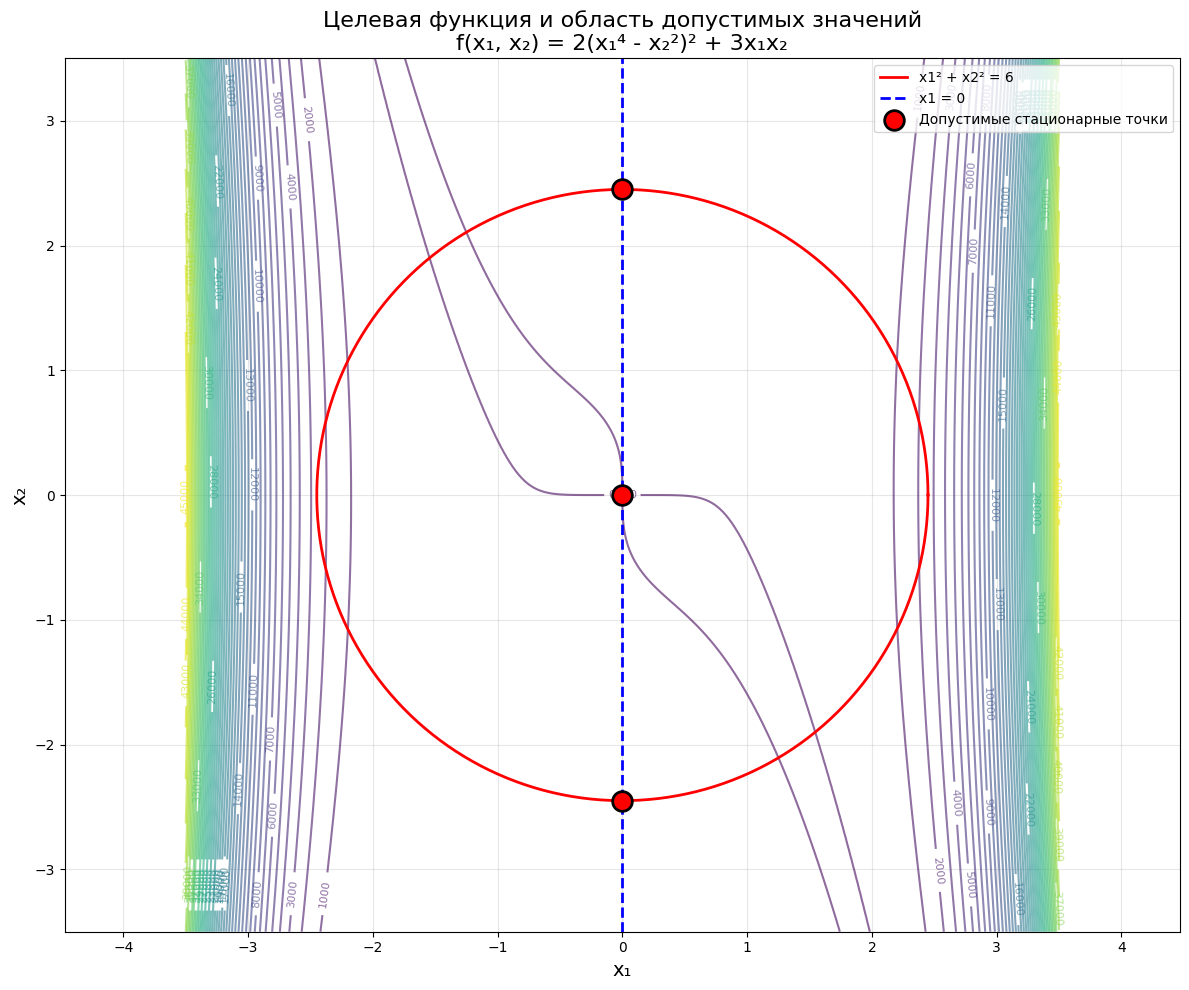

График сохранен как 'optimization_plot.png'


In [9]:
print("\n" + "="*60)
print("8. ВИЗУАЛИЗАЦИЯ")
print("="*60)

x_vals = np.linspace(-3.5, 3.5, 300)
y_vals = np.linspace(-3.5, 3.5, 300)
X, Y = np.meshgrid(x_vals, y_vals)
Z = 2 * (X**4 - Y**2)**2 + 3 * X * Y

plt.figure(figsize=(12, 10))

contour = plt.contour(X, Y, Z, levels=50, cmap='viridis', alpha=0.6)
plt.clabel(contour, inline=True, fontsize=8)

theta = np.linspace(0, 2*np.pi, 200)
plt.plot(np.sqrt(6)*np.cos(theta), np.sqrt(6)*np.sin(theta), 
         'r-', linewidth=2, label='x1² + x2² = 6')
plt.axvline(x=0, color='b', linestyle='--', linewidth=2, label='x1 = 0')

first_feasible = True
first_infeasible = True

for r in results:
    x1_val = float(r['x1'])
    x2_val = float(r['x2'])
    
    if r['feasible']:
        color = 'red'
        label = 'Допустимые стационарные точки' if first_feasible else ''
        plt.scatter(x1_val, x2_val, color=color, s=200, 
                    zorder=5, label=label, edgecolors='black', linewidth=2)
        first_feasible = False
    else:
        color = 'gray'
        label = 'Недопустимые точки' if first_infeasible else ''
        plt.scatter(x1_val, x2_val, color=color, s=100, 
                    zorder=5, label=label, edgecolors='black', linewidth=1, alpha=0.5)
        first_infeasible = False

plt.xlabel('x₁', fontsize=14)
plt.ylabel('x₂', fontsize=14)
plt.title('Целевая функция и область допустимых значений\n' + 
          'f(x₁, x₂) = 2(x₁⁴ - x₂²)² + 3x₁x₂', fontsize=16)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.xlim(-3.5, 3.5)
plt.ylim(-3.5, 3.5)

plt.tight_layout()
plt.savefig('optimization_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("График сохранен как 'optimization_plot.png'")

# 9. Итоговый вывод

In [10]:
print("\n" + "="*60)
print("9. ИТОГОВЫЙ ВЫВОД")
print("="*60)

feasible_results = [r for r in results if r['feasible']]

if feasible_results:
    print(f"\nНайдено {len(feasible_results)} допустимых стационарных точек.\n")
    
    for r in feasible_results:
        print(f"Точка: ({r['x1']}, {r['x2']})")
        print(f"  f(x) = {r['f']}")
        
        H_point = H.subs({
            x1: r['x1'], 
            x2: r['x2'], 
            l1: r['l1'], 
            l2: r['l2']
        })
        H_matrix = sp.Matrix(H_point)
        minors = [H_matrix[:k, :k].det() for k in range(1, H_matrix.rows + 1)]
        
        if all(m > 0 for m in minors):
            print(f"  Тип: ЛОКАЛЬНЫЙ МИНИМУМ")
        elif all(m < 0 for m in minors) and len(minors) % 2 == 0:
            print(f"  Тип: ЛОКАЛЬНЫЙ МАКСИМУМ")
        else:
            print(f"  Тип: СЕДЛОВАЯ ТОЧКА")
        
        print()
else:
    print("\nДопустимых стационарных точек не найдено.")

print("="*60)
print("РАБОТА ЗАВЕРШЕНА")
print("="*60)


9. ИТОГОВЫЙ ВЫВОД

Найдено 3 допустимых стационарных точек.

Точка: (0, -sqrt(6))
  f(x) = 72
  Тип: ЛОКАЛЬНЫЙ МАКСИМУМ

Точка: (0, sqrt(6))
  f(x) = 72
  Тип: ЛОКАЛЬНЫЙ МАКСИМУМ

Точка: (0, 0)
  f(x) = 0
  Тип: СЕДЛОВАЯ ТОЧКА

РАБОТА ЗАВЕРШЕНА
